In [4]:
"""
Emotion Classification using CNN 
=========================================================
โค้ดนี้โหลดข้อมูลจากไฟล์ CSV ปรับสมดุลข้อมูลด้วยการสุ่มตัวอย่างที่ต้องการ
ทำการ Tokenization และ Padding ข้อความ จากนั้นสร้างโมเดล CNN เพื่อจำแนกอารมณ์
และประเมินผล รวมทั้งแสดงกราฟผลการเทรนและ Confusion Matrix
"""

'\nEmotion Classification using CNN \n=========================================================\nโค้ดนี้โหลดข้อมูลจากไฟล์ CSV ปรับสมดุลข้อมูลด้วยการสุ่มตัวอย่างที่ต้องการ\nทำการ Tokenization และ Padding ข้อความ จากนั้นสร้างโมเดล CNN เพื่อจำแนกอารมณ์\nและประเมินผล รวมทั้งแสดงกราฟผลการเทรนและ Confusion Matrix\n'

# === Import Libraries ===

In [3]:
import re
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall

# === Load Data ===

Train Data:
                                                Text  Emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger

Validation Data:
                                                Text  Emotion
0  im feeling quite sad and sorry for myself but ...  sadness
1  i feel like i am still looking at a blank canv...  sadness
2                     i feel like a faithful servant     love
3                  i am just feeling cranky and blue    anger
4  i can have for a treat or if i am feeling festive      joy

Test Data:
                                                Text  Emotion
0  im feeling rather rotten so im not very ambiti...  sadness
1          im updating my blog because i feel shitty  sadness
2  i never make her separate

C:\Users\User\AppData\Local\Temp\ipykernel_20752\657842667.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Emotion', order=order, palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_20752\657842667.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Emotion', order=order, palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_20752\657842667.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Emotion', order=order, palette="viridis")


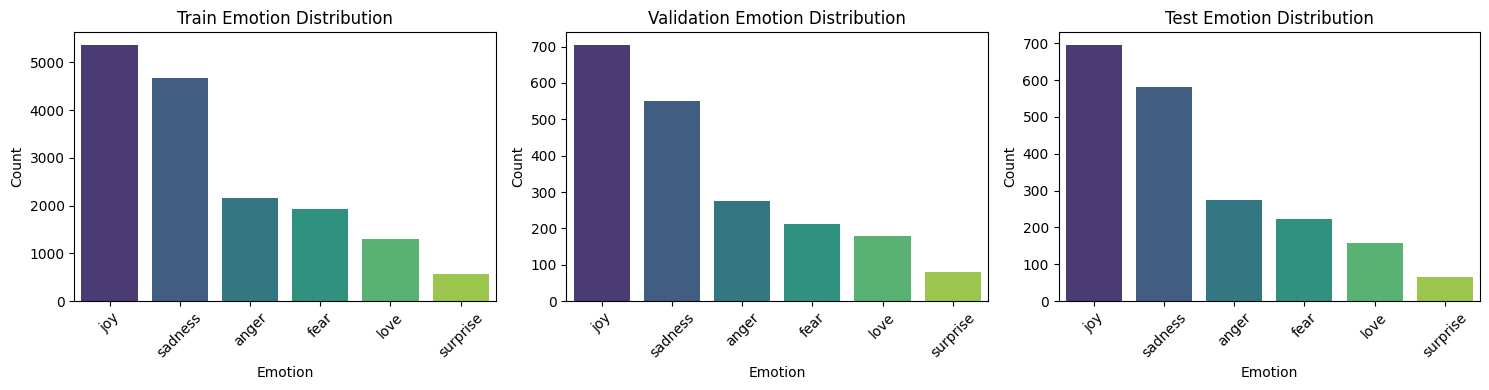

In [12]:
df_train = pd.read_csv('../dataset/train.txt', names=['Text', 'Emotion'], sep=';')
df_val   = pd.read_csv('../dataset/val.txt', names=['Text', 'Emotion'], sep=';')
df_test  = pd.read_csv('../dataset/test.txt', names=['Text', 'Emotion'], sep=';')

# แสดงตัวอย่างข้อมูลและข้อมูลเบื้องต้น
print("Train Data:")
print(df_train.head())
print("\nValidation Data:")
print(df_val.head())
print("\nTest Data:")
print(df_test.head())

print(f"\nTrain set: {df_train.shape[0]} rows, {df_train.shape[1]} columns")
print(f"Validation set: {df_val.shape[0]} rows, {df_val.shape[1]} columns")
print(f"Test set: {df_test.shape[0]} rows, {df_test.shape[1]} columns")
print("Unique Emotions in Train:", df_train['Emotion'].unique())
print("Missing Values in Train:", df_train.isnull().sum().sum())
print("Duplicates in Train:", df_train.duplicated().sum())

# === Plot Emotion Distribution (ก่อนปรับสมดุล) ===
plt.figure(figsize=(15,4))
for i, (data, title) in enumerate(zip([df_train, df_val, df_test],
                                      ["Train Emotion Distribution", "Validation Emotion Distribution", "Test Emotion Distribution"])):
    plt.subplot(1,3,i+1)
    order = data['Emotion'].value_counts().index
    sns.countplot(data=data, x='Emotion', order=order, palette="viridis")
    plt.title(title)
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Data Balancing ===

In [14]:
# นับจำนวนข้อมูลในแต่ละอารมณ์โดยใช้ value_counts()
train_counts = df_train['Emotion'].value_counts()
val_counts   = df_val['Emotion'].value_counts()
test_counts  = df_test['Emotion'].value_counts()

# ดึงค่า count ของแต่ละ label ถ้าไม่มีจะได้ 0
love_train = train_counts.get('love', 0)
love_val   = val_counts.get('love', 0)
love_test  = test_counts.get('love', 0)

sad_train  = train_counts.get('sadness', 0)
sad_val    = val_counts.get('sadness', 0)
sad_test   = test_counts.get('sadness', 0)

joy_train  = train_counts.get('joy', 0)
joy_val    = val_counts.get('joy', 0)
joy_test   = test_counts.get('joy', 0)

fear_train = train_counts.get('fear', 0)
fear_val   = val_counts.get('fear', 0)
fear_test  = test_counts.get('fear', 0)

anger_train = train_counts.get('anger', 0)
anger_val   = val_counts.get('anger', 0)
anger_test  = test_counts.get('anger', 0)

# แสดงผลข้อมูลออกมา
print("จำนวนข้อมูลแต่ละ label:")
print("love:")
print("  Train:", love_train)
print("  Validation:", love_val)
print("  Test:", love_test)
print("----------")
print("sad:")
print("  Train:", sad_train)
print("  Validation:", sad_val)
print("  Test:", sad_test)
print("----------")
print("joy:")
print("  Train:", joy_train)
print("  Validation:", joy_val)
print("  Test:", joy_test)
print("----------")
print("fear:")
print("  Train:", fear_train)
print("  Validation:", fear_val)
print("  Test:", fear_test)
print("----------")
print("anger:")
print("  Train:", anger_train)
print("  Validation:", anger_val)
print("  Test:", anger_test)



จำนวนข้อมูลแต่ละ label:
love:
  Train: 1304
  Validation: 178
  Test: 159
----------
sad:
  Train: 4666
  Validation: 550
  Test: 581
----------
joy:
  Train: 5362
  Validation: 704
  Test: 695
----------
fear:
  Train: 1937
  Validation: 212
  Test: 224
----------
anger:
  Train: 2159
  Validation: 275
  Test: 275


In [17]:
# กรองข้อมูลที่มี 'surprise' ออก (ไม่คำนึงถึงตัวพิมพ์)

df_train = df_train[~df_train['Emotion'].str.contains('surprise', case=False)]
df_val   = df_val[~df_val['Emotion'].str.contains('surprise', case=False)]
df_test  = df_test[~df_test['Emotion'].str.contains('surprise', case=False)]

# สำหรับ Train: กำหนดจำนวนตัวอย่างให้แต่ละอารมณ์
joy_train   = df_train[df_train['Emotion'] == 'joy'].sample(n=2200, random_state=20)
sad_train   = df_train[df_train['Emotion'] == 'sadness'].sample(n=2200, random_state=20)
fear_train  = df_train[df_train['Emotion'] == 'fear'].sample(n=1937, random_state=20)
anger_train = df_train[df_train['Emotion'] == 'anger'].sample(n=2159, random_state=20)
love_train  = df_train[df_train['Emotion'] == 'love'].sample(n=1304, random_state=20)
df_train_bal = pd.concat([joy_train, sad_train, fear_train, anger_train, love_train]).sample(frac=1, random_state=20).reset_index(drop=True)

# สำหรับ Validation
joy_val   = df_val[df_val['Emotion'] == 'joy'].sample(n=250, random_state=20)
sad_val   = df_val[df_val['Emotion'] == 'sadness'].sample(n=250, random_state=20)
fear_val  = df_val[df_val['Emotion'] == 'fear'].sample(n=212, random_state=20)
anger_val = df_val[df_val['Emotion'] == 'anger'].sample(n=275, random_state=20)
love_val  = df_val[df_val['Emotion'] == 'love'].sample(n=178, random_state=20)
df_val_bal = pd.concat([joy_val, sad_val, fear_val, anger_val, love_val]).sample(frac=1, random_state=20).reset_index(drop=True)

# สำหรับ Test
joy_test   = df_test[df_test['Emotion'] == 'joy'].sample(n=250, random_state=20)
sad_test   = df_test[df_test['Emotion'] == 'sadness'].sample(n=250, random_state=20)
fear_test  = df_test[df_test['Emotion'] == 'fear'].sample(n=224, random_state=20)
anger_test = df_test[df_test['Emotion'] == 'anger'].sample(n=275, random_state=20)
love_test  = df_test[df_test['Emotion'] == 'love'].sample(n=159, random_state=20)
df_test_bal = pd.concat([joy_test, sad_test, fear_test, anger_test, love_test]).sample(frac=1, random_state=20).reset_index(drop=True)

C:\Users\User\AppData\Local\Temp\ipykernel_20752\3658950922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Emotion', order=order, palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_20752\3658950922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Emotion', order=order, palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_20752\3658950922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Emotion', order=order, palette="viridis")


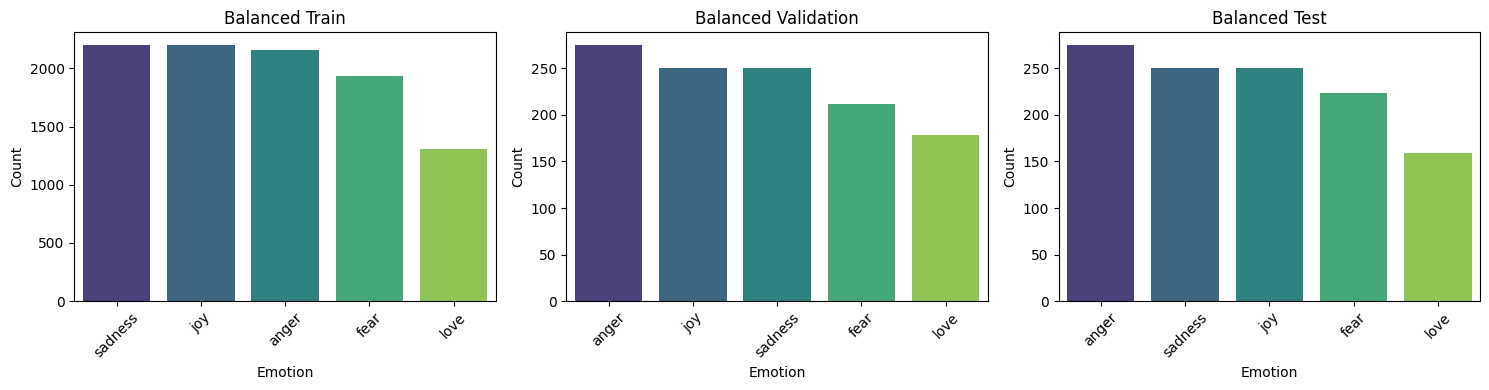

In [19]:
# Plot หลังปรับสมดุล
plt.figure(figsize=(15,4))
for i, (data, title) in enumerate(zip([df_train_bal, df_val_bal, df_test_bal],
                                      ["Balanced Train", "Balanced Validation", "Balanced Test"])):
    plt.subplot(1,3,i+1)
    order = data['Emotion'].value_counts().index
    sns.countplot(data=data, x='Emotion', order=order, palette="viridis")
    plt.title(title)
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# === Prepare Data for Modeling ===
X_train = df_train_bal['Text']
y_train = df_train_bal['Emotion']
X_val   = df_val_bal['Text']
y_val   = df_val_bal['Emotion']
X_test  = df_test_bal['Text']
y_test  = df_test_bal['Emotion']

In [23]:
# Encode labels เป็นตัวเลขและแปลงเป็น One-Hot Encoding
label_encoder = LabelEncoder()
y_train_enc = to_categorical(label_encoder.fit_transform(y_train))
y_val_enc   = to_categorical(label_encoder.transform(y_val))
y_test_enc  = to_categorical(label_encoder.transform(y_test))

# Tokenization และ Padding
max_words = 10000
max_len   = 50
embedding_dim = 32

text_tokenizer = Tokenizer(num_words=max_words)
text_tokenizer.fit_on_texts(X_train)
X_train_seq = text_tokenizer.texts_to_sequences(X_train)
X_val_seq   = text_tokenizer.texts_to_sequences(X_val)
X_test_seq  = text_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

In [27]:
# === Build CNN Model ===
from tensorflow.keras.utils import plot_model
inp = Input(shape=(max_len,))
x = Embedding(max_words, embedding_dim)(inp)
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(5, activation='softmax')(x)

model = Model(inputs=inp, outputs=out)
model.compile(optimizer=Adamax(),
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(), Recall()])

# สร้างและบันทึกไดอะแกรมของโมเดล
plot_model(model, to_file="model_structure.png", show_shapes=True, show_layer_names=True)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,781 (1.33 MB)

 Trainable params: 347,653 (1.33 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.2090 - loss: 1.7179 - precision: 0.2145 - recall: 0.0121 - val_accuracy: 0.2352 - val_loss: 1.6074 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2270 - loss: 1.6144 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2429 - val_loss: 1.6073 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2396 - loss: 1.5975 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2429 - val_loss: 1.6065 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2387 - loss: 1.5910 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.2498 - val_loss: 1.6057 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2666 - loss: 1.5804 - precision: 0.0000e+00

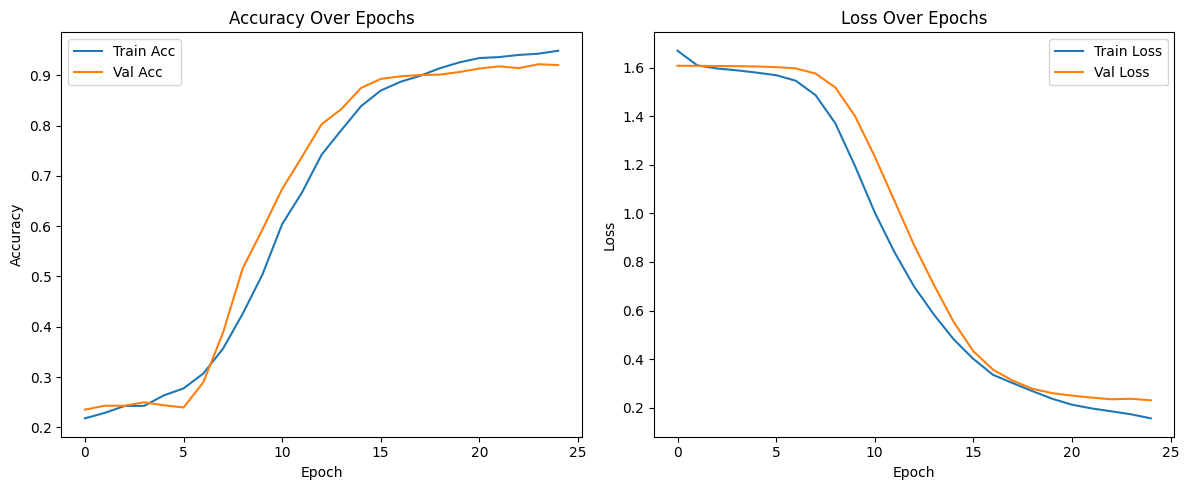

In [16]:
# === Train the Model ===
history = model.fit(X_train_pad, y_train_enc,
                    epochs=25,
                    validation_data=(X_val_pad, y_val_enc),
                    batch_size=256)

# === Evaluate the Model ===
loss_val, acc_val, prec_val, rec_val = model.evaluate(X_test_pad, y_test_enc, verbose=0)
print(f"Test Loss: {loss_val:.4f}")
print(f"Test Accuracy: {acc_val:.4f}")
print(f"Test Precision: {prec_val:.4f}")
print(f"Test Recall: {rec_val:.4f}")

# === Plot Training History ===
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


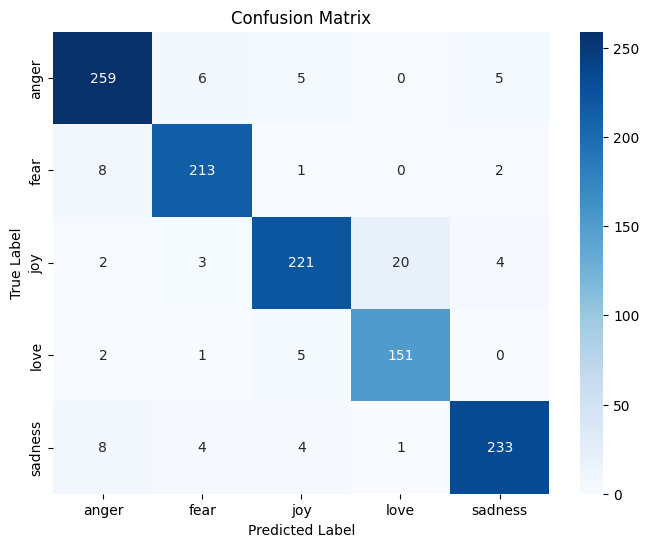

In [17]:
# === Save the Model and Tokenizer ===

model.save('sentiment_analysis_model.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(text_tokenizer, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
# === Confusion Matrix ===
y_test_true = np.argmax(y_test_enc, axis=1)
pred_probs  = model.predict(X_test_pad)
y_test_pred = np.argmax(pred_probs, axis=1)
cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(8,6))
emotion_labels = sorted(label_encoder.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# === Prediction Examples ===
sample_texts = [
    "I am very happy to finish this project",
    "I am very sad",
    "I think, I am afraid.",
    "i want to be with you forever",
    "you are lying!!"
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


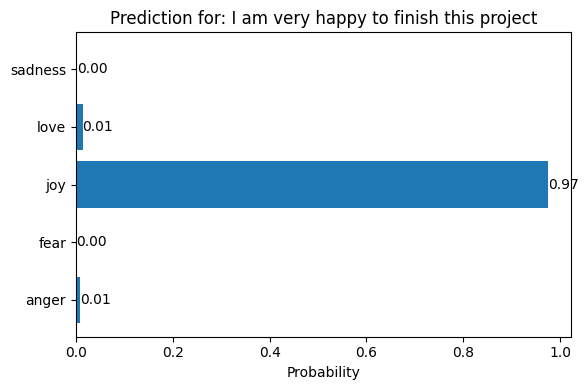

Input: I am very happy to finish this project
Predicted Emotion: joy
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


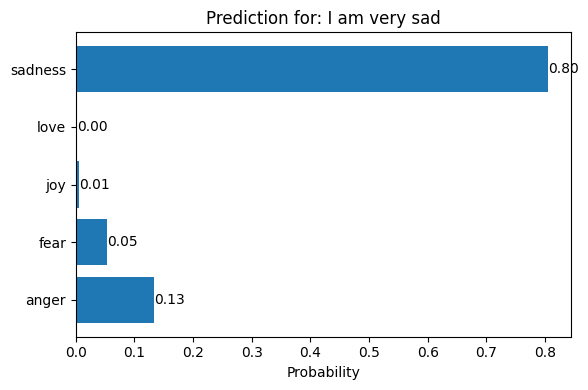

Input: I am very sad
Predicted Emotion: sadness
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


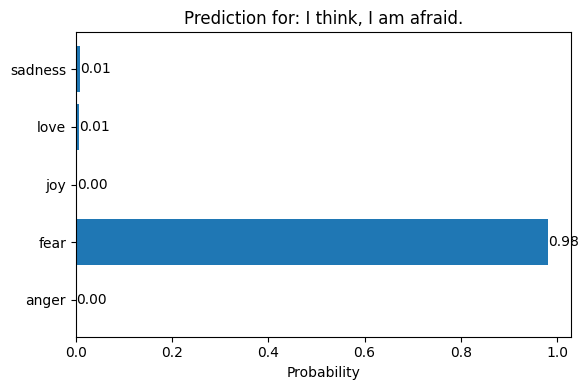

Input: I think, I am afraid.
Predicted Emotion: fear
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


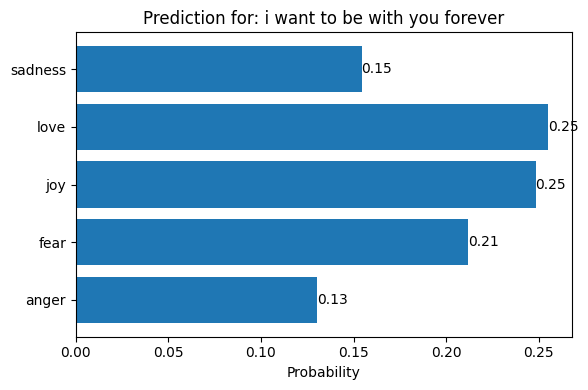

Input: i want to be with you forever
Predicted Emotion: love
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


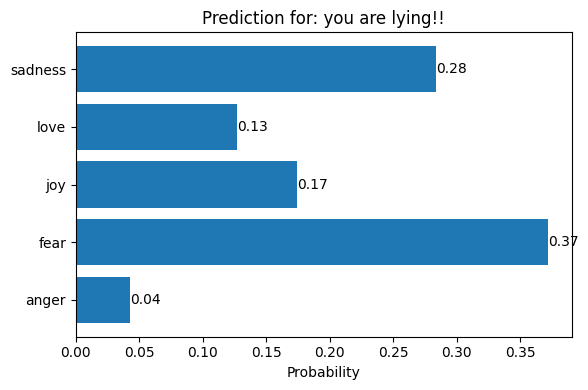

Input: you are lying!!
Predicted Emotion: fear
----------------------------------------


In [18]:
for txt in sample_texts:
    seq = text_tokenizer.texts_to_sequences([txt])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(padded)
    pred_label_index = np.argmax(pred)
    pred_emotion = label_encoder.inverse_transform([pred_label_index])[0]
    # Plot ความน่าจะเป็นของแต่ละอารมณ์
    plt.figure(figsize=(6,4))
    probs = pred[0]
    emotions = [label_encoder.inverse_transform([i])[0] for i in range(len(probs))]
    bars = plt.barh(emotions, probs)
    plt.xlabel("Probability")
    plt.title("Prediction for: " + txt)
    plt.gca().bar_label(bars, fmt="%.2f")
    plt.tight_layout()
    plt.show()
    print(f"Input: {txt}\nPredicted Emotion: {pred_emotion}\n{'-'*40}")